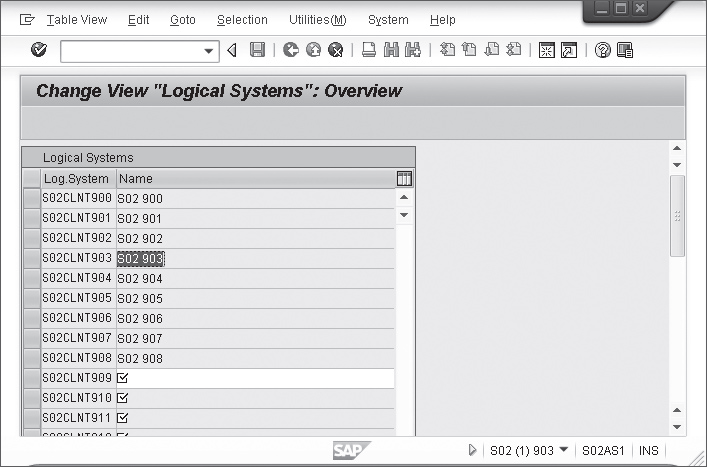

在 SAP 系统中，事务代码 **BD54** 的核心作用是**定义和管理逻辑系统（Logical Systems）**。

在 SAP 的分布式架构（如 ALE、IDoc 或 PI/PO 接口场景）中，它相当于**全网的“通信地址簿”**。

### 1. 为什么需要 BD54？

SAP 系统之间进行数据交换时，为了防止数据发错对象或被来源不明的请求干扰，每个参与通信的 SAP 实例都必须拥有一个**在全球范围内唯一的身份标识**。这个标识就是“逻辑系统”。

BD54 的主要功能就是在这个“地址簿”中为系统“挂名”。

### 2. 它的核心功能

* **创建逻辑系统名称**：你可以在这里定义系统的唯一名称（通常遵循 `<SID>CLNT<client>` 格式，如 `ERPCLNT100`）。
* **建立识别机制**：当 IDoc 数据包到达系统 B 时，系统 B 会检查数据包里的发件人代码。如果这个代码在系统 B 的 BD54 中找不到，系统会直接报错拒绝（通常提示“Logical system XXX is not known”）。

### 3. 在接口场景中的重要性

如果你正在配置接口（如你之前提到的 System A 发送数据到 System B）：

1. **在 System A 中**：你需要通过 BD54 定义好自己的名字。
2. **在 System B 中**：你**也必须**在 BD54 中手动录入 System A 的名字。
3. **结果**：只有这样，双方才能在后续的合作伙伴协议（Partner Profile，事务代码 `WE20`）中把对方添加为可信任的通信伙伴。

### 总结

你可以把 **BD54** 理解为：**为你的 SAP 系统申领一个“网络ID”**。如果这里的 ID 没配对，双方系统就像是两个完全陌生的公司，虽然有物理连接（RFC），但由于不认对方的身份，无法进行业务数据交换。

**操作提示：**
在进行接口调试时，如果你遇到“Logical system does not exist”类的报错，**第一个要检查的地方就是 BD54**，看看目标系统中是否已经录入了源系统的逻辑名。

你是在配置接口时遇到了“逻辑系统不存在”的错误，还是在进行基础的环境搭建？




we20
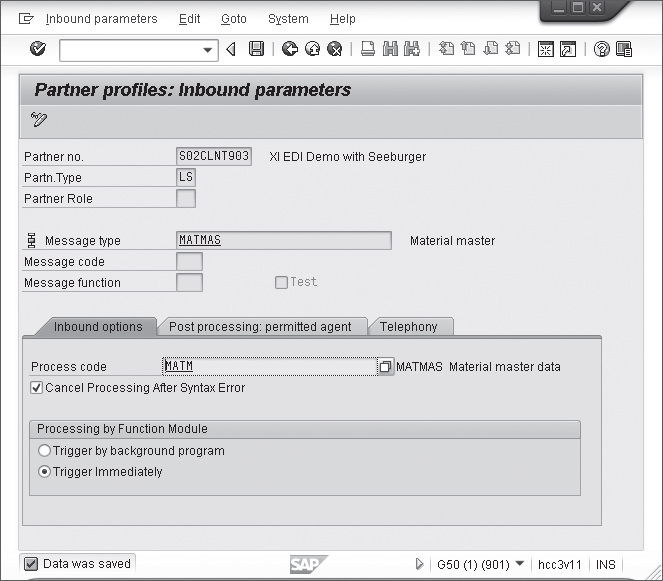
这段内容是在指导你如何完成 **WE20** 事务代码中的配置，这是在 SAP 中建立系统间信任关系的关键一步。在之前的 BD54 步骤中，你已经定义了逻辑系统的名称；现在，你需要使用 WE20 来告诉系统：“我确实接受并准备处理来自那个系统的数据”。

具体的操作步骤如下：

### 1. 创建合作伙伴协议 (Partner Agreement)

* 进入 **WE20** 后，通过菜单路径 `PARTNERS` -> `CREATE`（或者点击对应的创建图标）来新建一个协议。
* 在合作伙伴编号（Partner Number）处，输入你在之前 BD54 步骤中定义的系统 A 的逻辑系统名称。
* **非常重要**：在详细信息窗口中，必须将合作伙伴类型（Partner Type）选择为 **LS**（代表 Logical System）。
* 在“分类（Classification）”选项卡中，确保合作伙伴状态（Partner Status）设置为 **A**（代表 Active/激活）。

### 2. 配置入站参数 (Inbound Parameters)

这一步决定了当你收到数据时，系统该如何处理它。

* 保存刚才创建的合作伙伴协议。
* 在屏幕下方的“入站参数（Inbound parameters）”区域，点击“创建入站参数”图标。
* 在随后弹出的屏幕模板中，选择消息类型（Message Type）为 **MATMAS** (Master Material)。

**总结：**
这一连串操作的目的是告诉系统 B：“如果接收到来自系统 A 的、类型为 `MATMAS`（物料主数据）的 IDoc，请自动对其进行处理。” 完成这些配置后，接口的基础通信链路就打通了。


这段文字是关于在 SAP 中配置 **IDoc 入站参数（Inbound Parameters）** 的最后步骤，旨在完善你之前在 WE20 中建立的通信协议。

具体的操作指导如下：

* **选择流程代码（Process Code）**：在“入站选项（Inbound Options）”选项卡下，你需要选择预定义的流程代码 `MATM`。
* **关于错误处理的建议**：
* 在调试阶段，建议**不要**勾选“在语法错误后取消处理（Cancel processing after syntax error）”选项，这样即使出现语法错误，流程也不会立即终止，方便你后续定位和排查潜在问题。
* 一旦你的集成场景测试通过，你可以选择勾选该选项，以便在遇到语法错误时自动取消处理。


* **功能模块处理**：应立即执行“按功能模块处理（Processing by Function Module）”的选项。
* **最后步骤**：保存所有设置并退出当前事务。

完成这些步骤后，你已经成功创建了一个用于通过 IDoc 与系统 A 进行通信的合作伙伴协议。


这段内容主要是在指导你在 **Enterprise Services Repository (ESR)** 中为当前的“File-to-IDoc”练习进行对象设计。

以下是核心信息的解读：

* **复用设计对象**：教程指出，如果你已经完成了之前的练习，可以复用其中的部分对象。这些可复用的对象在表格中用星号（*）标识，包括 `MT_Material`（消息类型）和 `DT_Material`（数据类型）。
* **设计对象概览（Table 4.5）**：
* **发送方 (Sender Side)**：需要定义新的 `Service interface` (`SI_Material_Async_Out`)、`Operation mapping` 和 `Message mapping`。
* **接收方 (Receiver Side)**：直接使用标准对象 `MATMAS.MATMAS02`。


* **操作指引**：
* 你需要创建一个新的服务接口 `SI_Material_Async_Out`。
* 在创建时，该接口应选择 **OUTBOUND**（出站）类别，并且模式设置为 **ASYNCHRONOUS**（异步）。
* 输出消息（Output message）应关联到你在上一个练习中已经创建好的 `MT_Material` 消息类型。



简单来说，这是在构建接口开发的“蓝图”，通过复用旧组件和创建少量新接口定义，为将数据从文件（File）同步到 IDoc 系统做好准备。

请问你是需要在 SAP PI/PO 的 ESR 环境中进行这些对象的创建吗？
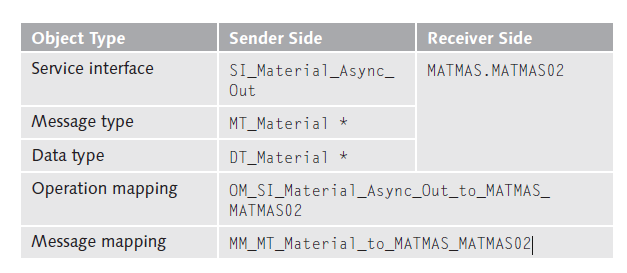
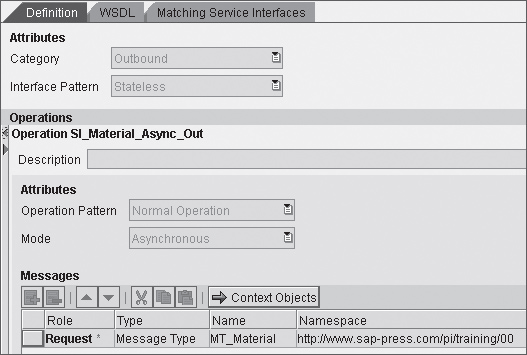

这段内容指导你如何在 SAP PI/PO 的 ESR 中完成接收方（Receiver Side）的元数据导入，这是实现 File-to-IDoc 接口的关键步骤。

### 核心任务解读

* **导入 IDoc 元数据**：为了让 SAP PI/PO 知道如何向目标系统发送 IDoc，你必须将 `MATMAS.MATMAS02` 这个 IDoc 的结构定义导入到 ESR 中。
* **操作方式**：
* 在 ESR 中，定位到你的软件组件版本（Software Component Version）。
* 找到“Imported Objects”目录，右键点击并选择导入（Import）对话框。
* 你需要从源系统（通常是业务系统 B）中提取并导入 IDoc 的定义。


* **为何这样做**：
* 一旦导入，这个 IDoc 的定义就可以直接充当“消息类型（Message Type）”和“服务接口（Service Interface）”。
* 这意味着你不需要再手动创建复杂的结构，直接使用系统生成的标准定义即可。



### 为什么这一步至关重要？

在集成开发中，IDoc 的结构（包含哪些字段、数据类型是什么）是由目标 SAP 系统决定的。通过“导入”操作，你确保了你的接口定义与目标系统的实际要求**保持一致**。

* **图 4.30 解释**：你已经完成了出站服务接口 (`SI_Material_Async_Out`) 的定义，现在通过导入 `MATMAS.MATMAS02`，你就拥有了接口的“两端”：
* **发送方**：`SI_Material_Async_Out` (你定义的出站逻辑)。
* **接收方**：`MATMAS.MATMAS02` (从系统导入的标准入站 IDoc 定义)。



接下来，你就可以在 Mapping 中将这两端连接起来，实现数据流的转换。这一步完成后，你的 ESR 设计工作就基本告一段落了，接下来通常就是进入 **Integration Directory** 进行配置了。

你在导入过程中遇到找不到 IDoc 定义的问题了吗？如果是在连接系统 B 时遇到 RFC 问题，记得检查之前配置的 RFC 通信用户权限。


这段话是你在 SAP PI/PO 开发过程中，进行消息映射（Message Mapping）阶段的具体实操指令。

简单来说，它的意思是：你需要完成从你的“源数据格式”到“SAP 标准 IDoc 格式”的转换逻辑。

以下是这一步操作的详细解读：

### 1. 任务目标

你要创建一个名为 `MM_MT_Material_to_MATMAS_MATMAS02` 的映射对象。

* **左侧（发送方）**：分配你之前创建好的 `MT_Material` 消息类型（即你定义的物料结构）。
* **右侧（接收方）**：分配你刚刚从系统中导入的 `MATMAS.MATMAS02` IDoc 类型（这是 SAP 系统接收物料数据的标准格式）。

### 2. 为什么这一步被描述为“挑战”？

IDoc 数据结构非常庞大，通常包含数百个字段（Segments），涵盖了物料主数据的方方面面。

* **复杂性**：对于新手来说，直接面对几百个字段会感到无从下手，因为你根本不知道哪些是必须填的，哪些是无关的。
* **Table 4.6 的作用**：教材提到 Table 4.6，就是为了帮你“减负”。这张表**筛选出了你这个练习中真正需要关注的字段**。你只需要关注表里列出的那几十个关键字段，而不需要管剩下的几百个。

### 3. 你接下来的核心工作

当你进入 `MM_MT_Material_to_MATMAS_MATMAS02` 的编辑界面后：

1. **加载结构**：将左侧的 `MT_Material` 和右侧的 `MATMAS.MATMAS02` 拖入映射编辑器。
2. **对照映射**：参考教材中的 Table 4.6，将左侧的数据字段一一拖拽连线到右侧对应的 IDoc 字段中。
* 例如：将左侧的 `MATNR` 连到右侧 `E1MARAM` 段下的 `MATNR` 字段。


3. **处理格式**：如果左右两边的字段格式不一致，你可能还需要像之前练习一样，调用函数（如 `FormatNumber` 或字符串处理函数）进行转换。

### 操作建议

在进行这项工作时，请确保你的 **Table 4.6** 手边可见。**不要试图去填满右侧的所有字段**，那样会极大增加报错的风险。只要完成了表中列出的关键字段映射，该接口在 SAP 系统中通常就能成功创建物料记录了。

你在映射过程中，如果找不到 Table 4.6 里某个字段在 IDoc 里的具体位置，可以告诉我字段名，我帮你定位它在哪个 Segment（片段）下。

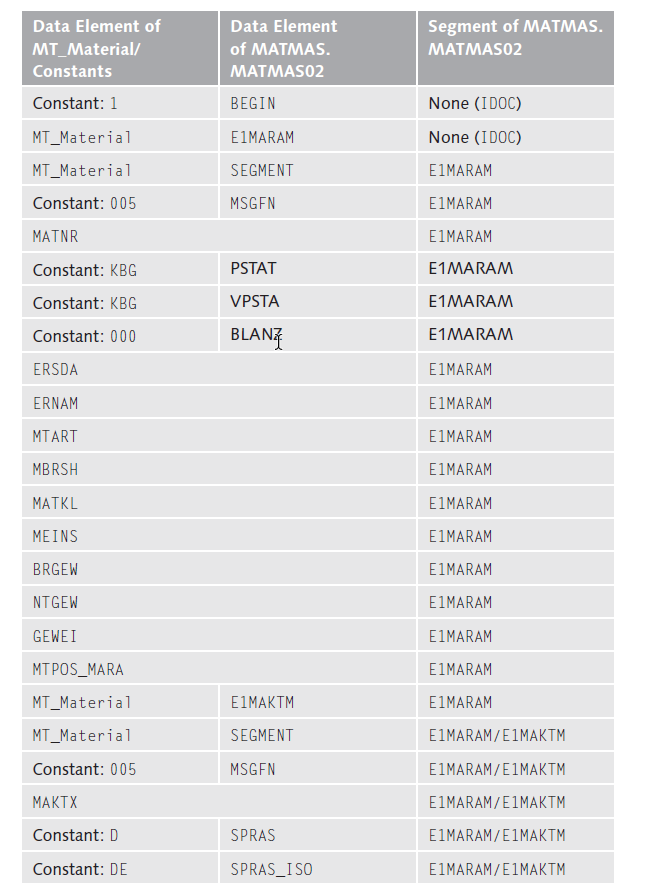

这段内容为你提供了在 SAP PI/PO 中完成 `MM_MT_Material_to_MATMAS_MATMAS02` 消息映射的**具体实操指南**。它不仅告诉你如何映射字段，还解释了为什么有些字段必须手动填入“常量（Constant）”。

### 1. 核心映射指南 (表 4.6 解析)

`image_3dce3f.png` 展示了详细的字段对应关系。请注意以下关键点：

* **常量映射**：并非所有数据都来自你的源文件。例如 `MSGFN` 字段必须填入常量 `005`（表示“创建或修改”），`SPRASH` 必须填 `D`（德语），这些是 IDoc 协议要求的业务逻辑值。
* **结构层级**：明确了哪些字段属于 `E1MARAM`（物料主数据头段），哪些属于 `E1MAKT`（物料描述子段）。

### 2. IDoc 的特殊结构要点

`image_3dce00.png` 解释了 IDoc 结构的深层逻辑：

* **BEGIN 与 SEGMENT 字段**：这些字段控制 IDoc 的生成逻辑。`BEGIN` 必须赋值，而 `SEGMENT` 字段决定了数据包中有多少个层级。
* **MSGFN 字段**：这是每个 IDoc 片段中必有的，`005` 是关键的业务常数，告诉接收系统这些数据是用来“创建或更新”的。
* **WE60 事务代码**：如果你想查询某个 IDoc 类型的具体含义或文档，可以在 SAP 系统中执行事务代码 `WE60`。

### 3. 如何优化映射（关键操作提示）

由于 `MATMAS` IDoc 非常庞大，包含数百个你根本用不到的字段，教材给出了一条非常实用的建议：

* **禁用冗余字段**：为了防止接口报错或数据冗余，你应该禁用（Disable）所有不必要的段。
* **操作方法**：在映射编辑器中，对不需要的段点击右键，选择 **"Disable Field"**。
* **保留范围**：只保留 `E1MARAM` 及其子段 `E1MAKTM` 即可，其他全部禁用。

---

**建议你的操作顺序：**

1. 参照 `image_3dce3f.png` 中的表格，将字段一一拖拽对应。
2. 在映射中添加所需的常量（如 `005`, `D`, `DE` 等）。
3. **务必执行禁用操作**，将所有未使用的 IDoc 段禁用，这样你的映射界面会清爽很多，且后续测试更不容易出错。

你在操作“禁用字段（Disable Field）”时遇到困难了吗？如果有字段删不掉，记得检查一下它是不是被其他逻辑引用了。


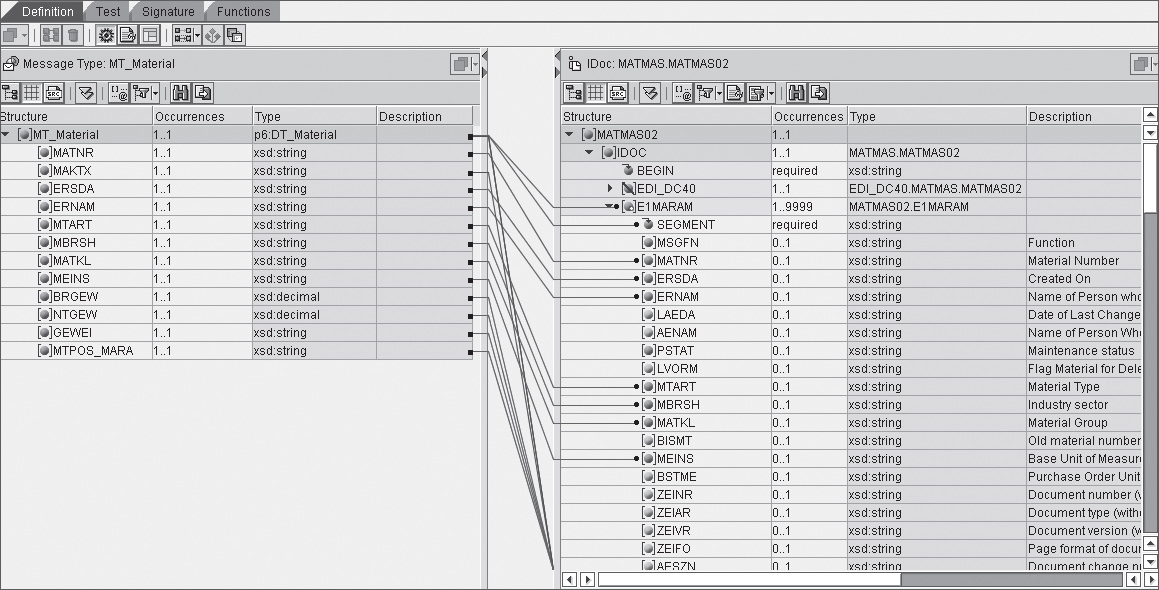


这段内容是在指导你完成 SAP PI/PO 开发流程中的最后一步 ESR（企业服务库）设计工作：**创建操作映射（Operation Mapping）**。

### 1. 核心任务：创建操作映射

操作映射（Operation Mapping）是连接服务接口的“桥梁”。它将你之前创建好的**消息映射**（即数据字段对应关系）打包封装，并绑定具体的发送和接收接口。

### 2. 具体操作步骤

* **命名**：创建一个名为 `OM_MI_Material_Async_Out_to_MATMAS_MATMAS02` 的操作映射对象。
* **关联接口**：
* 发送方（Sender）接口：选择 `SI_Material_Async_Out`。
* 接收方（Receiver）接口：选择 `MATMAS.MATMAS02`。


* **绑定逻辑**：将你之前做好的消息映射 `MM_MT_Material_to_MATMAS_MATMAS02` 指定给这个操作映射。
* **测试与保存**：在界面的 **TEST** 选项卡下测试你的映射配置，确认无误后保存对象。

### 3. 图 4.31 的含义

`image_3dc772.jpg` 展示了映射界面：

* 左侧是你的源结构（`MT_Material`），右侧是目标 IDoc 结构（`MATMAS.MATMAS02`）。
* 线条连接了对应的字段，代表了数据如何从文件源系统通过 PI/PO 处理并最终流向 SAP IDoc。

**总结：**
这一步完成后，你的接口设计对象就已经全部构建完毕，接下来就可以进入 **Integration Directory** 层面进行具体的运行配置（如配置通信通道等）了。

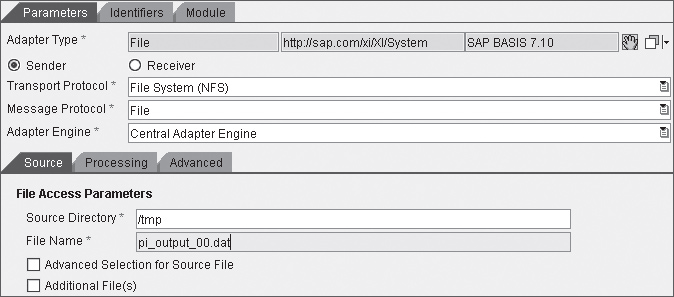
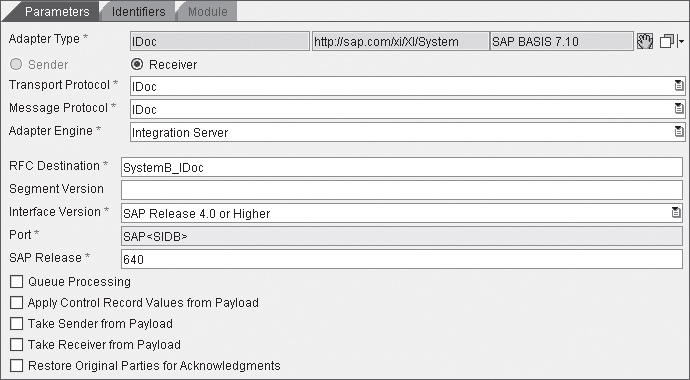

这张图片展示的是 SAP 集成练习中的 **“端到端验证” (End-to-End Verification)** 环节，即如何确认你之前配置的集成场景是否已经成功运行。

简单来说，这是一个“触发-处理-校验”的过程，步骤如下：

### 1. 触发流程 (Triggering the Process)

* **动作**：在发送方系统的指定目录下创建一个名为 `pi_input_##.dat` 的文件。
* **目的**：这是为了模拟外部系统向 SAP 发送数据。如果你之前做过练习，程序 `Z_PROG_MATERIALINPUT_##` 可以自动帮你生成这个文件。

### 2. 系统后台处理 (Background Processing)

* **机制**：SAP PI/PO 的“通信通道”（Communication Channel）会定期扫描该文件夹。
* **现象**：一旦文件被读取并处理，它通常会被系统移动到归档目录或直接删除。如果文件消失了，说明适配器已经成功捕获并启动了消息处理流程。

### 3. 结果校验 (Verification in SAP)

这是图片重点展示的内容，用于验证数据是否成功写入了接收方系统 (Business System B)：

* **操作**：进入 **Transaction MM03**（这是 SAP 中显示物料主数据的标准事务码）。
* **校验对象**：输入你在文件中定义的物料名称（例如 `PI_BOOK-##`）。
* **选择视图**：如图中所示，你需要选择 **Basic Data 1** 和 **Basic Data 2** 视图，这是为了查看刚才集成流程导入的数据明细。

### 总结

这其实是在告诉你：**“配置完成后，如何通过业务操作来验证接口是否真的起效了。”**

如果在这个界面能查看到对应的物料信息，说明从“文件输入 -> SAP PI 传输 -> IDoc 接收 -> 创建物料主数据”这一整套集成链路是完全打通且正常的。

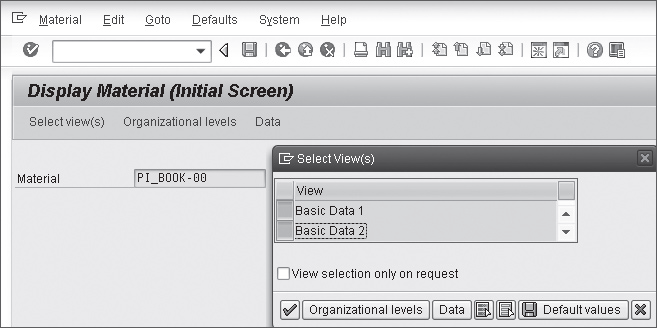



这张图片的内容是关于 **SAP PI/PO 集成故障排查（Troubleshooting）** 的指南。当你在练习中发现数据没有按预期传送到接收系统（System B）时，该文档提供了一套标准的排查路径：

### 1. 如何分析数据结构 (Extending the sent data)

如果你想深入了解 SAP 界面字段与 IDoc（中间文档）字段的对应关系，可以使用以下技巧：

* **Transaction WE60**：查看完整的 IDoc 类型文档（包含所有字段定义）。
* **F1 帮助键**：在 MM03 界面选中某个字段按 `F1`，然后点击“技术信息”（Technical Information）图标。在“Field Data”区域，通常能找到与 IDoc 字段名匹配的准确名称。

### 2. 核心排查步骤 (Checking the file processing)

如果物料未创建，请按顺序检查以下三个层面：

* **第一步：检查适配器状态 (File Adapter)**
* **位置**：Runtime Workbench 中的“组件监控”（Component Monitoring）。
* **原因**：如果文件适配器没有读取或归档文件，说明接口甚至还没能启动。


* **第二步：检查消息监控 (Message Monitoring)**
* **位置**：Transaction **SXMB_MONI** 或 Runtime Workbench。
* **状态判定**：
* 如果看到“黑白格子旗”（black-and-white checkered flag）图标，说明 PI 系统已成功将消息发送给目标系统。
* 如果有错误，可以分析是否为集成对象的内容错误。




* **第三步：检查技术交付 (Technical Delivery)**
* **位置**：Transaction **SM58**。
* **用途**：查看是否存在 tRFC（事务性 RFC）相关的技术故障。例如，如果连接失败，可能是因为在准备练习系统时，相关的“合作伙伴协议”（Partner Agreement）配置缺失或配置错误导致的。



---

**总结**：这部分内容是教你作为一名集成开发人员，如何通过 **WE60**（理解结构）、**SXMB_MONI**（监控集成流）和 **SM58**（跟踪技术通信）这三个核心工具，定位接口运行失败的根本原因。这对你日常处理 ABAP 接口集成任务是非常实用的调试手段。

你需要针对某个具体的报错代码进行深入排查吗？




这几张图的内容是关于 **SAP IDoc 接收端处理的深度故障排查**。如果你的数据已经成功发送到了接收系统（System B），但业务数据（如物料主数据）没有正确创建，你需要使用 **BD87** 这个事务码来定位原因。

以下是操作逻辑的逐步拆解：

### 1. 核心工具：事务码 BD87 (ALE 状态监控器)

* **用途**：它是 SAP 中专门用来监控和处理 IDoc（中间文档）流入流出状态的核心工具。
* **操作方法**：
* 在 System B 中运行 `BD87`。
* 直接点击执行（Execute），系统会列出当天处理的所有 IDoc 及其当前状态。



### 2. 如何通过状态分析错误 (Figure 4.39)

屏幕上会按状态分类显示 IDoc，重点关注以下两种：

* **IDoc ready to be transferred to application (状态 64)**：表示 IDoc 已经到达系统，但还没被处理。
* **Application document posted (状态 53)**：表示已成功处理。

如果你的业务数据没出现，通常会看到其他代表“失败”的状态码（例如状态 51，表示报错）。

### 3. 如何定位具体报错原因 (Figure 4.40 逻辑)

当你通过层级点击进入具体的 IDoc 后，系统会进入详细视图，你可以执行以下操作来抓取“报错真相”：

* **查看状态记录**：展开左侧的“Status records”目录。
* **获取详细日志**：
* 点击菜单栏的 **GOTO -> Application Log**。
* **关键作用**：这里会直接显示具体的业务错误原因，例如“某字段缺失”、“字段数据格式不正确”或“物料代码已存在”等。



### 总结

这套流程是处理接口问题的“终极手段”：

1. **SXMB_MONI** 告诉你是“消息发送成功了没”（PI 层）。
2. **BD87** 告诉你“数据进系统后，为什么没能写入业务数据库”（应用层）。

如果你在 `Application Log` 中看到具体的错误代码或描述，你可以把报错信息发给我，我可以帮你分析具体的配置或数据问题。



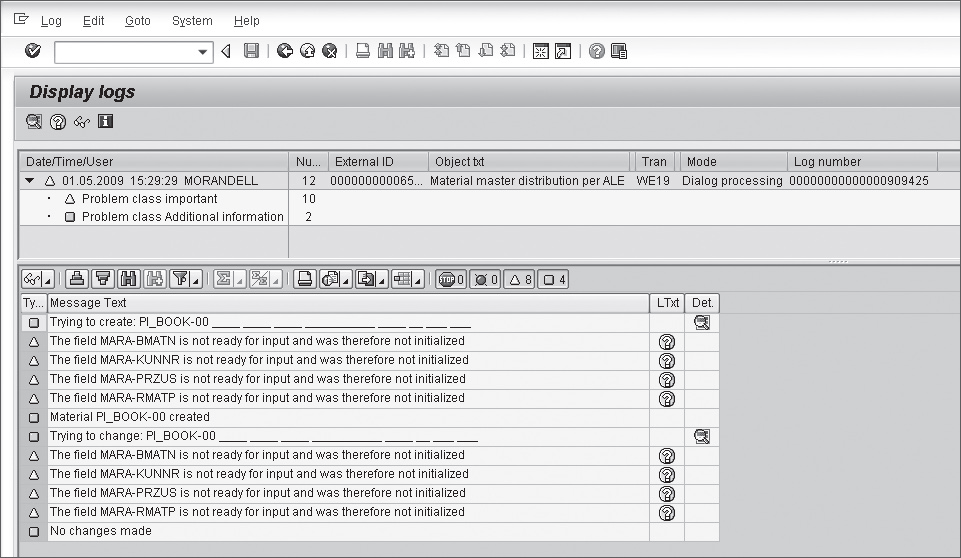



